In [3]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [4]:
!kaggle datasets download -d salader/dogsvscats


Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
 99% 1.05G/1.06G [00:08<00:00, 348MB/s]
100% 1.06G/1.06G [00:08<00:00, 134MB/s]


In [5]:
import zipfile
import os

zip_path = "dogsvscats.zip"       # Kaggle se jo zip milega
extract_path = "dogs_vs_cats"     # naya folder jisme extract hoga

# Folder bana lo agar pehle se na ho
os.makedirs(extract_path, exist_ok=True)

# Extract karo
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted to:", extract_path)


✅ Dataset extracted to: dogs_vs_cats


In [6]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import  Dense, Flatten

from tensorflow.keras.applications.vgg16 import VGG16

In [7]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(150,150,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [8]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [9]:
conv_base.trainable = False

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
# 1) Import libraries
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 2) Yahan augmentation add karo
train_datagen = ImageDataGenerator(
    rescale=1./150,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# 3) Dataset load karo
train_generator = train_datagen.flow_from_directory(
    "dogs_vs_cats/train",
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary"
)

val_generator = test_datagen.flow_from_directory(
    "dogs_vs_cats/test",
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary"
)



Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [12]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [14]:
history = model.fit(
        train_generator,
        epochs=10,
        validation_data=val_generator)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 177s 269ms/step - accuracy: 0.8405 - loss: 0.3723 - val_accuracy: 0.8944 - val_loss: 0.2450
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 163s 261ms/step - accuracy: 0.8839 - loss: 0.2629 - val_accuracy: 0.9024 - val_loss: 0.2284
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 261ms/step - accuracy: 0.9022 - loss: 0.2299 - val_accuracy: 0.9054 - val_loss: 0.2237
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 162s 259ms/step - accuracy: 0.9046 - loss: 0.2215 - val_accuracy: 0.9054 - val_loss: 0.2203
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 162s 259ms/step - accuracy: 0.9047 - loss: 0.2180 - val_accuracy: 0.9070 - val_loss: 0.2173
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 164s 262ms/step - accuracy: 0.9077 - loss: 0.2140 - val_accuracy: 0.8986 - val_loss: 0.2343
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 168s 269ms/step - accuracy: 0.9139 - loss: 0.2019 - val_accuracy: 0.8922 - val_loss: 0.2396
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 167s 268ms/step - accuracy: 0.9134 -

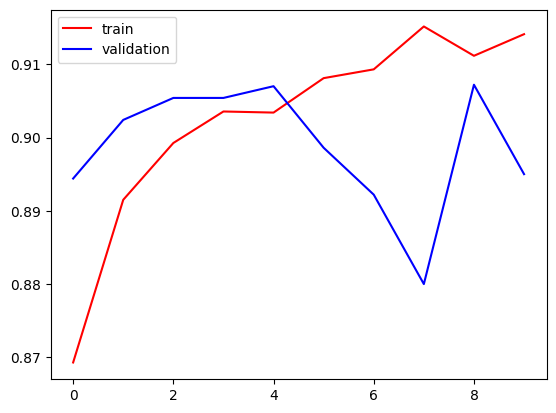

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

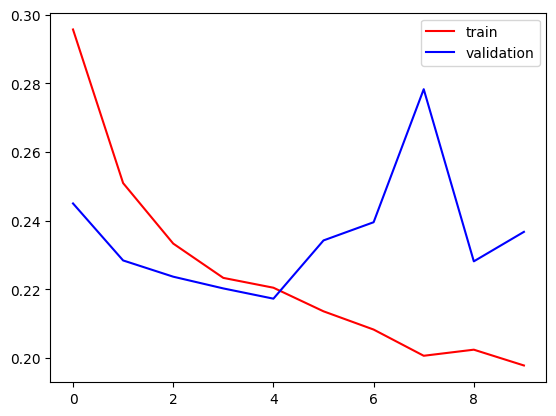

In [16]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()